In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from pandas.plotting import andrews_curves
dataset=pd.read_csv(r"./DATASET/Iris.csv")
dataset.head(55)
dataset.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


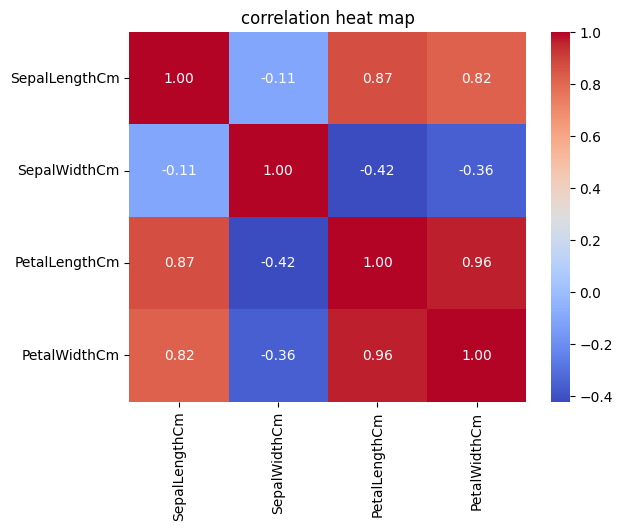

In [3]:
numeric_data=(dataset.drop(columns=["Id","Species"]))
corr=numeric_data.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation heat map')
plt.show()

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
dataset.duplicated().sum()

np.int64(0)

In [6]:
dataset[dataset.duplicated()]

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species


In [7]:
dataset.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
numeric_data_tsne=dataset.drop(columns=['Id'])
numeric_data_tsne['Species']=numeric_data_tsne['Species'].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})
species_names = numeric_data_tsne['Species'].map({0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'})

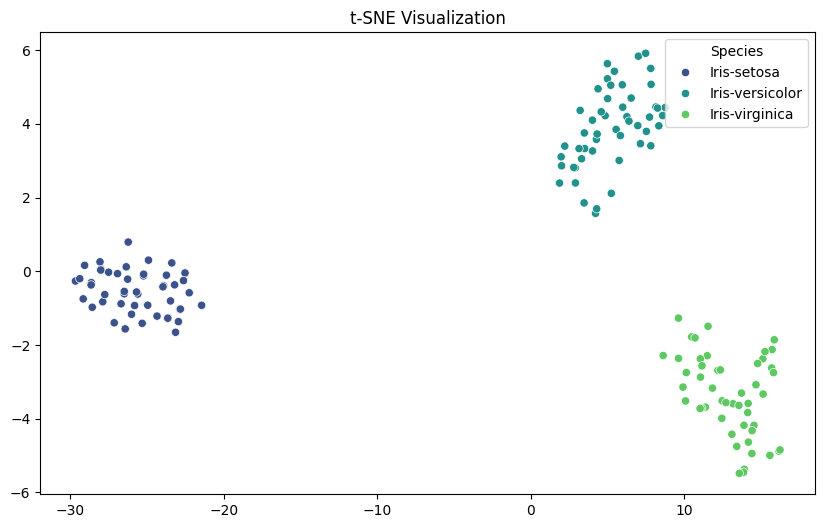

In [9]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(numeric_data_tsne)
tsne=TSNE(n_components=2,random_state=42)
tsne_results=tsne.fit_transform(scaled_data)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1],hue=species_names, palette='viridis')
plt.title('t-SNE Visualization')
plt.show()

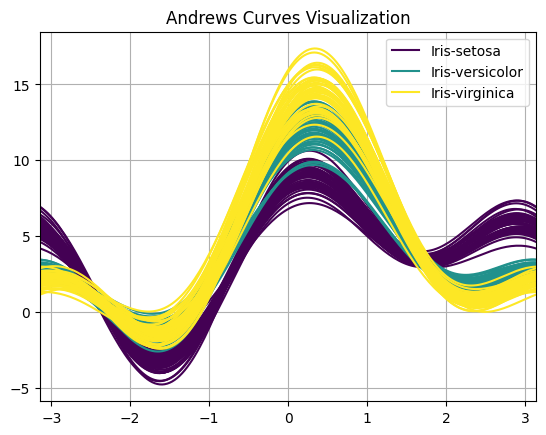

In [10]:
#plt.figure(figsize=(10, 6))
andrews_curves(numeric_data.join(species_names.rename('Species_Name')), 'Species_Name', colormap='viridis')

plt.title('Andrews Curves Visualization')
plt.show()

In [11]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(dataset[numeric_cols])

scaled_dataset = pd.DataFrame(scaled_features, columns=numeric_cols)
scaled_dataset['Id'] = dataset['Id']
scaled_dataset['Species'] = dataset['Species']
scaled_dataset = scaled_dataset[['Id'] + numeric_cols + ['Species']]

scaled_dataset.head()